In [10]:
import numpy as np
import importlib.util
from pathlib import Path

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#local plotting functions
spec = importlib.util.spec_from_file_location('plot_init', root / 'functions' / 'plot_init.py')
plot_init = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_init)

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import matplotlib.gridspec as gridspec
import matplotlib.tri as tri
import cartopy.feature as cfeature
import shapely.geometry
from matplotlib.colors import LogNorm


In [11]:
def readgrid(fn):
    with open(fn) as f:
        #Read the WW3 nodes
        for _ in range(4):
            f.readline()
        n_nodes = int(f.readline())
        lon,lat = [],[]
        for _ in range(n_nodes):
            row = f.readline().split()
            lon.append(float(row[1]))
            lat.append(float(row[2]))

        #Read triangles, skipping boundary edges
        for _ in range(2):
            f.readline()
        n_elements = int(f.readline())
        elements = []
        for _ in range(n_elements):
            row = f.readline().split()
            if len(row) == 6:
                continue
            elements.append([int(row[6]), int(row[7]), int(row[8])])

    return np.array(lat), np.array(lon), np.array(elements)


def gridres(elements,lat,lon):
    #Shortest connected edge at each node, in metres
    resolution = np.full(len(lat), np.inf)
    for node1,node2,node3 in elements - 1:
        for i,j in [(node1,node2), (node2,node3), (node3,node1)]:
            length = _haversine(lat[i], lon[i], lat[j], lon[j])
            resolution[i] = min(resolution[i], length)
            resolution[j] = min(resolution[j], length)
    return resolution


def _haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on the Earth specified in degrees.
    """

    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


In [12]:
fn = root / 'Data' / 'mesh.ww3'
lat,lon,elements = readgrid(fn)
ww3res = gridres(elements,lat,lon)


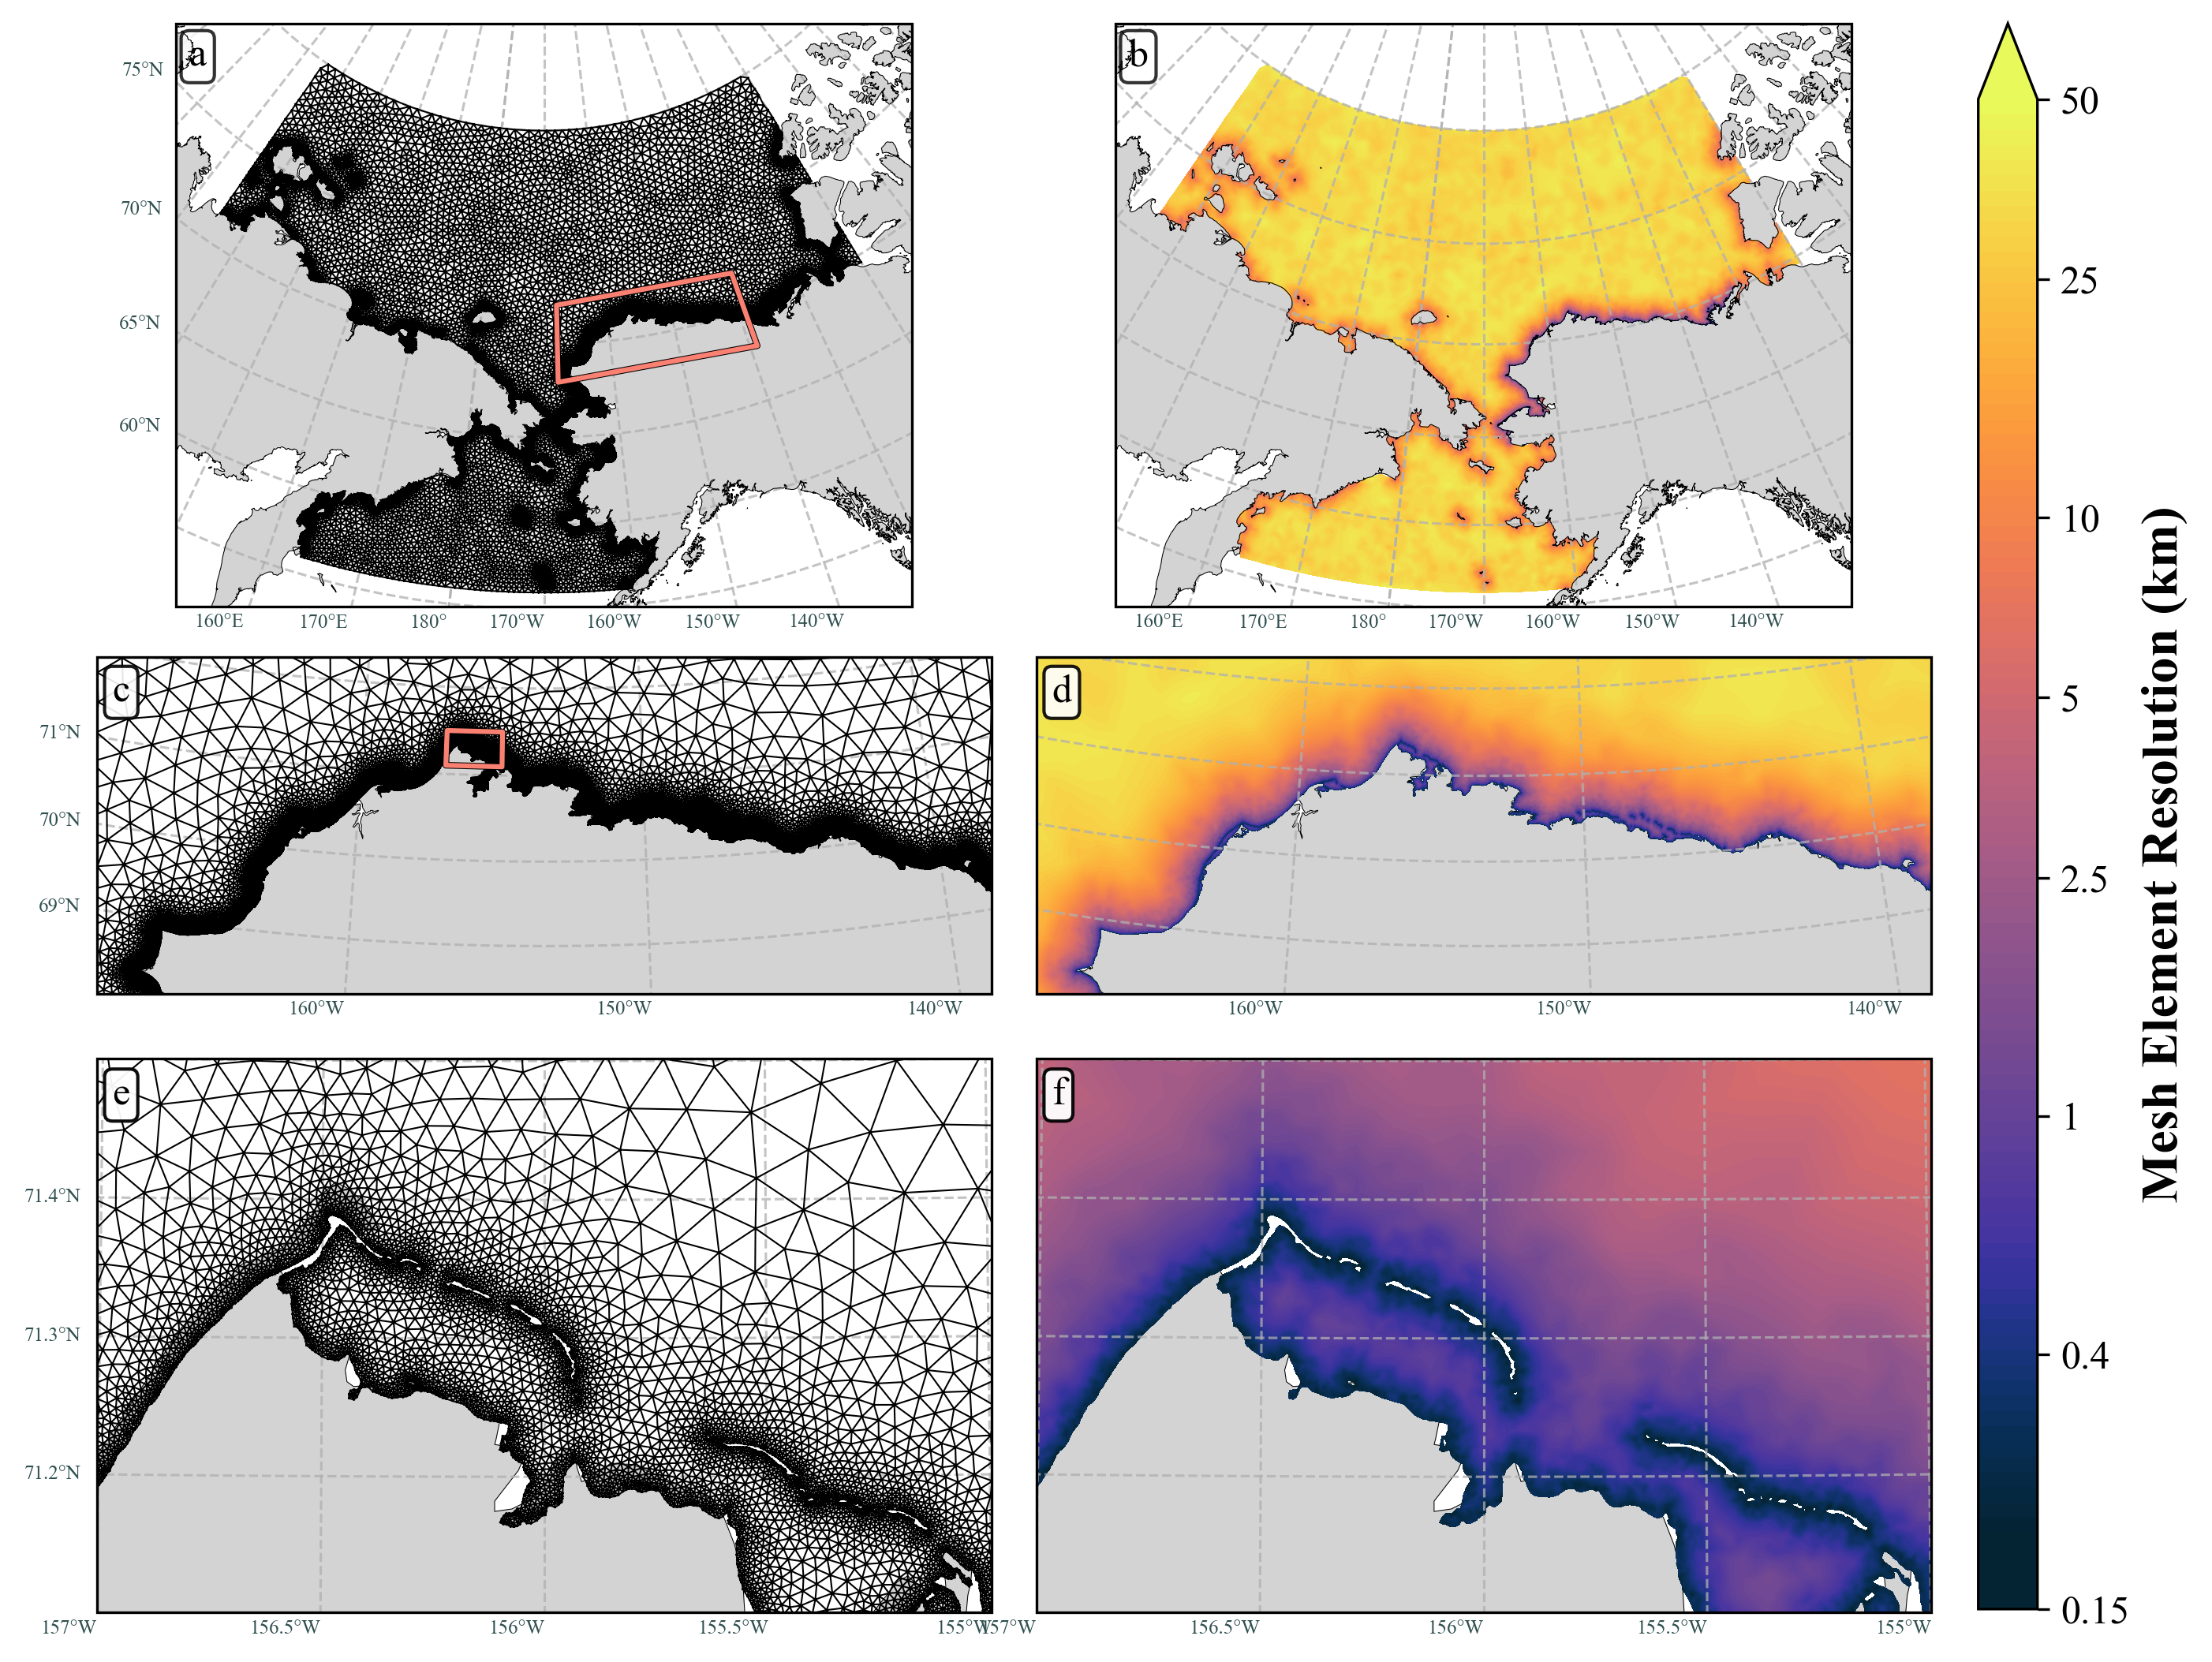

In [13]:

def get_gridlines(ax,xticks,yticks):
    gl = ax.gridlines(draw_labels=True, linestyle='--',
                      xlocs=xticks, ylocs=yticks, alpha=0.75,
                      x_inline=False, y_inline=False,
                      zorder=50, linewidth=0.75)
    return gl

def gl_styler(gl,subplot=None):
    if subplot is None:
        raise ValueError("subplot must be provided")
    
    if subplot == 'left':
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.xlabel_style = {'size': 6, 'rotation': 0, 'color': 'darkslategrey'}
        gl.ylabel_style = {'size': 6, 'rotation': 0, 'color': 'darkslategrey'}
    if subplot == 'right':
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.xlabel_style = {'size': 6, 'rotation': 0, 'color': 'darkslategrey'}
        gl.ylabel_style = {'size': 6, 'rotation': 0, 'color': 'darkslategrey'}
    

######### Init the fig ###########
fig = plt.figure(figsize=(10,10),dpi = 300)
gs = gridspec.GridSpec(4, 2, width_ratios=[1,1], height_ratios=[1,2,1,1],hspace=-0.5,wspace=0.05)
plt.rc('font', family='Times New Roman')


############### First Plot Row #################
proj,extent = plot_init.arctic_projection(option='arctic')
xnew, ynew, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
triang = tri.Triangulation(xnew,ynew, triangles=elements-1)
xticks = np.arange(-180, 180+10, 10)
yticks = np.arange(45, 90+5, 5)


ax00 = fig.add_subplot(gs[0,0], projection=proj)
ax00.set_extent(extent, crs=ccrs.PlateCarree())
ax00.add_feature(cfeature.LAND, facecolor='lightgray')
ax00.coastlines(resolution='10m', color='black', linewidth=0.25,zorder=4)
ax00.triplot(triang, color='black', linewidth=0.5, zorder=3)
labx,laby = 0.0175, 0.927
ax00.text(labx, laby, 'a', transform=ax00.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.8, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax00, xticks, yticks)
gl_styler(gl, subplot='left')

ax01 = fig.add_subplot(gs[0,1], projection=proj)
ax01.set_extent(extent, crs=ccrs.PlateCarree())
ax01.add_feature(cfeature.LAND, facecolor='lightgray')
ax01.coastlines(resolution='10m', color='black', linewidth=0.25,zorder=4)
cmap = cmocean.cm.thermal
levels = np.logspace(np.log10(0.15), np.log10(50), num=100)
cf0 = ax01.tricontourf(triang, ww3res / 1000, levels=levels, cmap=cmap, norm=LogNorm(vmin=0.2, vmax=50), zorder=2, extend='max')
ax01.text(labx, laby, 'b', transform=ax01.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.8, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax01, xticks, yticks)
gl_styler(gl, subplot='right')

########### Second Plot Row #################
proj,extent = plot_init.arctic_projection()
xnew, ynew, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
triang = tri.Triangulation(xnew,ynew, triangles=elements-1)
xticks = np.arange(-180, 180+10, 10)
yticks = np.arange(65, 85+5, 1)

ax10 = fig.add_subplot(gs[1:2,0], projection=proj)
ax10.set_extent(extent, crs=ccrs.PlateCarree())
ax10.add_feature(cfeature.LAND, facecolor='lightgray')
ax10.coastlines(resolution='10m', color='black', linewidth=0.25,zorder=4)
ax10.triplot(triang, color='black', linewidth=0.5, zorder=3)
ax10.text(labx, laby-0.06, 'c', transform=ax10.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.9, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax10, xticks, yticks)
gl_styler(gl, subplot='left')




ax11 = fig.add_subplot(gs[1:2,1], projection=proj)
ax11.set_extent(extent, crs=ccrs.PlateCarree())
ax11.add_feature(cfeature.LAND, facecolor='lightgray')
ax11.coastlines(resolution='10m', color='black', linewidth=0.25)
cf1 = ax11.tricontourf(triang, ww3res / 1000, levels=levels, cmap=cmap, norm=LogNorm(vmin=0.2, vmax=50), zorder=2, extend='max')
ax11.text(labx, laby-0.06, 'd', transform=ax11.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.9, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax11, xticks, yticks)
gl_styler(gl, subplot='right')

northcoastrect = shapely.geometry.box(extent[0], extent[2], extent[1], extent[3])
ax00.add_geometries([northcoastrect], ccrs.PlateCarree(), facecolor='none', edgecolor='salmon', linewidth=1.5,zorder =4)
ax00.add_geometries([northcoastrect], ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=2,zorder =3)




############### Third Plot Row #################
proj,extent = plot_init.arctic_projection(option='utq')
xnew, ynew, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
triang = tri.Triangulation(xnew,ynew, triangles=elements-1)
dx,dy = 0.5, 0.1
xticks = np.arange(-160, -140, dx)
yticks = np.arange(67, 75, dy)


ax20 = fig.add_subplot(gs[2:3,0], projection=proj)
ax20.set_extent(extent, crs=ccrs.PlateCarree())
ax20.add_feature(cfeature.LAND, facecolor='lightgray')
ax20.coastlines(resolution='10m', color='black', linewidth=0.25)
ax20.triplot(triang, color='black', linewidth=0.5, zorder=3)
ax20.text(labx, laby-0.01, 'e', transform=ax20.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.95, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax20, xticks, yticks)
gl_styler(gl, subplot='left')


ax21 = fig.add_subplot(gs[2:3,1], projection=proj)
ax21.set_extent(extent, crs=ccrs.PlateCarree())
ax21.add_feature(cfeature.LAND, facecolor='lightgray')
ax21.coastlines(resolution='10m', color='black', linewidth=0.25)
cf2 = ax21.tricontourf(triang, ww3res / 1000, levels=levels, cmap=cmap, norm=LogNorm(vmin=0.2, vmax=50), zorder=2, extend='max')
ax21.text(labx, laby-0.01, 'f', transform=ax21.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.95, boxstyle='round,pad=0.2'))
gl = get_gridlines(ax21, xticks, yticks)
gl_styler(gl, subplot='right')


barrowrect = shapely.geometry.box(extent[0], extent[2], extent[1], extent[3])
ax10.add_geometries([barrowrect], ccrs.PlateCarree(), facecolor='none', edgecolor='salmon', linewidth=1.5,zorder =4)
ax10.add_geometries([barrowrect], ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=2,zorder =3)



########### Colorbar Setup ############
cbar_ax = fig.add_axes([0.92, 0.21, 0.025, 0.67])  # [left, bottom, width, height]
cbar = plt.colorbar(cf0, cax=cbar_ax, orientation='vertical')
cbar.set_label('Mesh Element Resolution (km)', fontsize=16,fontweight='bold')
ticks = [0.15, 0.4, 1, 2.5, 5, 10, 25, 50]  # Logarithmic ticks
cbar.set_ticks(ticks)
cbar.ax.set_yticklabels([str(t) for t in ticks], fontsize=12)  # Optional: Format tick labels

# Save the figure
plt.savefig(root / 'Figures' / 'mesh.png', bbox_inches='tight', dpi=300)
